# LearnM8 Visualization Demo

This notebook demonstrates the 4-panel dashboard visualization for active learning progress using real molecular data from the AmpC β-lactamase screening dataset.

## Overview

The visualization shows:
1. **Panel 1**: Predicted vs True Activity (docking scores)
2. **Panel 2**: Uncertainty vs Prediction scatter
3. **Panel 3**: Prediction Distribution histogram
4. **Panel 4**: Cumulative Performance metrics (RMSE, R², Top-K recovery)

## Setup

In [1]:
import sys
sys.path.insert(0, '/home/tony/LearnM8')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML, Image

from learnm8 import run_active_learning
from learnm8.oracles import CSVOracle
from learnm8.visualization import create_dashboard_animation_from_csv

## Load Real Molecular Data from AmpC Dataset

Load and subsample 5,000 compounds from the AmpC 100K screening dataset.

**Dataset**: AmpC β-lactamase inhibitor screening with docking scores
- Lower docking scores = better binding affinity
- Active learning goal: Efficiently identify strong binders

In [2]:
ampc_file = '/home/tony/Compound_Libraries/LearnM8_datasets/AmpC/subsampled_data/AmpC_screen_100K.csv'

print("Loading AmpC screening data...")
full_data = pd.read_csv(ampc_file)
print(f"Full dataset: {len(full_data):,} compounds")

np.random.seed(42)
subsample_indices = np.random.choice(len(full_data), size=30000, replace=False)
compound_pool = full_data.iloc[subsample_indices].copy().reset_index(drop=True)

compound_pool = compound_pool.rename(columns={
    'zincid': 'ID',
    'smiles': 'SMILES',
})

compound_pool = compound_pool[['ID', 'SMILES', 'dockscore']]
compound_pool['dockscore'] = pd.to_numeric(compound_pool['dockscore'], errors='coerce')
compound_pool = compound_pool.dropna(subset=['dockscore']).reset_index(drop=True)

print(f"\nSubsampled to {len(compound_pool):,} compounds")
print(f"Docking score range: {compound_pool['dockscore'].min():.2f} to {compound_pool['dockscore'].max():.2f}")
print(f"Note: Lower docking scores indicate better binding affinity\n")
compound_pool.head()

Loading AmpC screening data...
Full dataset: 100,000 compounds

Subsampled to 29,054 compounds
Docking score range: -82.48 to 6.62
Note: Lower docking scores indicate better binding affinity



,ID,SMILES,dockscore
0,ZINC000338248522,O=C(CCc1cnc[nH]1)N[C@H](CO)CC1CCCC1,-38.93
1,ZINC000294817178,C[C@H]1CN(Cc2cccc(S(C)(=O)=O)c2)[C@@H](C)CO1,-33.98
2,ZINC000494929357,CCc1c(NC(=O)N2CCC(C)(CO)CC2)cnn1CCC(C)C,-33.58
3,ZINC000357109157,CC(C)[C@@H](CNC(=O)[C@@H](C)N1[C@H](C)CC[C@@H]...,-5.03
4,ZINC000450586655,CCO[C@H]1COCC[C@H]1NC(=O)Cc1ccc(O)c(F)c1,-29.06


## Save Dataset and Create Oracle

In [3]:
compound_pool.to_csv('ampc_5k_subsample.csv', index=False)
oracle = CSVOracle('ampc_5k_subsample.csv')
print("✓ Oracle created successfully")

✓ Oracle created successfully


## Run Active Learning with CSV Export

Run 15 cycles of active learning using Gaussian Process with UCB acquisition.

**Configuration**:
- **Learner**: Gaussian Process (provides uncertainty estimates)
- **Acquisition**: UCB (Upper Confidence Bound) - balances exploration/exploitation
- **Score Direction**: `lower` (for docking scores, lower = better binding)
- **Cycles**: 15
- **Batch Size**: 1% of dataset per cycle

In [4]:
results = run_active_learning(
    compound_pool=compound_pool,
    oracle=oracle,
    learner='rf_ensemble',
    target_column='dockscore',
    featurizer='morgan',
    strategy='ucb',
    n_cycles=15,
    initial_batch_fraction=0.01,
    batch_fraction=0.01,
    score_direction='lower',
    export_csv=True,
    output_dir='viz_demo_results',
    console_output=True
)

print(f"\n✓ Completed {results['total_cycles']} cycles")
print(f"✓ CSV files exported to: {results['output_dir']}")

                   📊 Cycle 0 (290 selected)                    
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Model Performance  ┃ Selection Quality  ┃ Benchmark Metrics  ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ R²: 0.530          │ Avg Sel: -30.231   │ Top-100: 4.0%      │
│ RMSE: 6.864        │ GT Avg: -30.659    │ Top-1K: 14.3%      │
│ MAE: 4.630         │ Labeled: 580       │ Top-0.1%: 3.5%     │
│ MSE: 47.108        │ Diversity: 0.869   │ Top-1%: 7.9%       │
│ Spearman: 0.759    │ Similarity: 0.000  │ Top-10%: 24.3%     │
│ Uncert μ: 0.607    │ Novelty: 0.000     │                    │
│ Uncert σ: 0.336    │                    │                    │
└────────────────────┴────────────────────┴────────────────────┘

                   📊 Cycle 1 (290 selected)                    
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Model Performance  ┃ Selection Quality  ┃ Benchmark Metrics  ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━

## Generate 4-Panel Dashboard Animation

Create animated visualization from the CSV exports showing:
- Prediction accuracy evolution
- Uncertainty-prediction relationship
- Sampling distribution
- Performance metrics over time

/home/tony/LearnM8/learnm8/visualization/animation.py:237: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax3.set_ylim(cumulative_best[-1] - y_range * 0.2, cumulative_best[0] + y_range * 0.2)


✓ Animation created: viz_demo_results/al_progress.gif


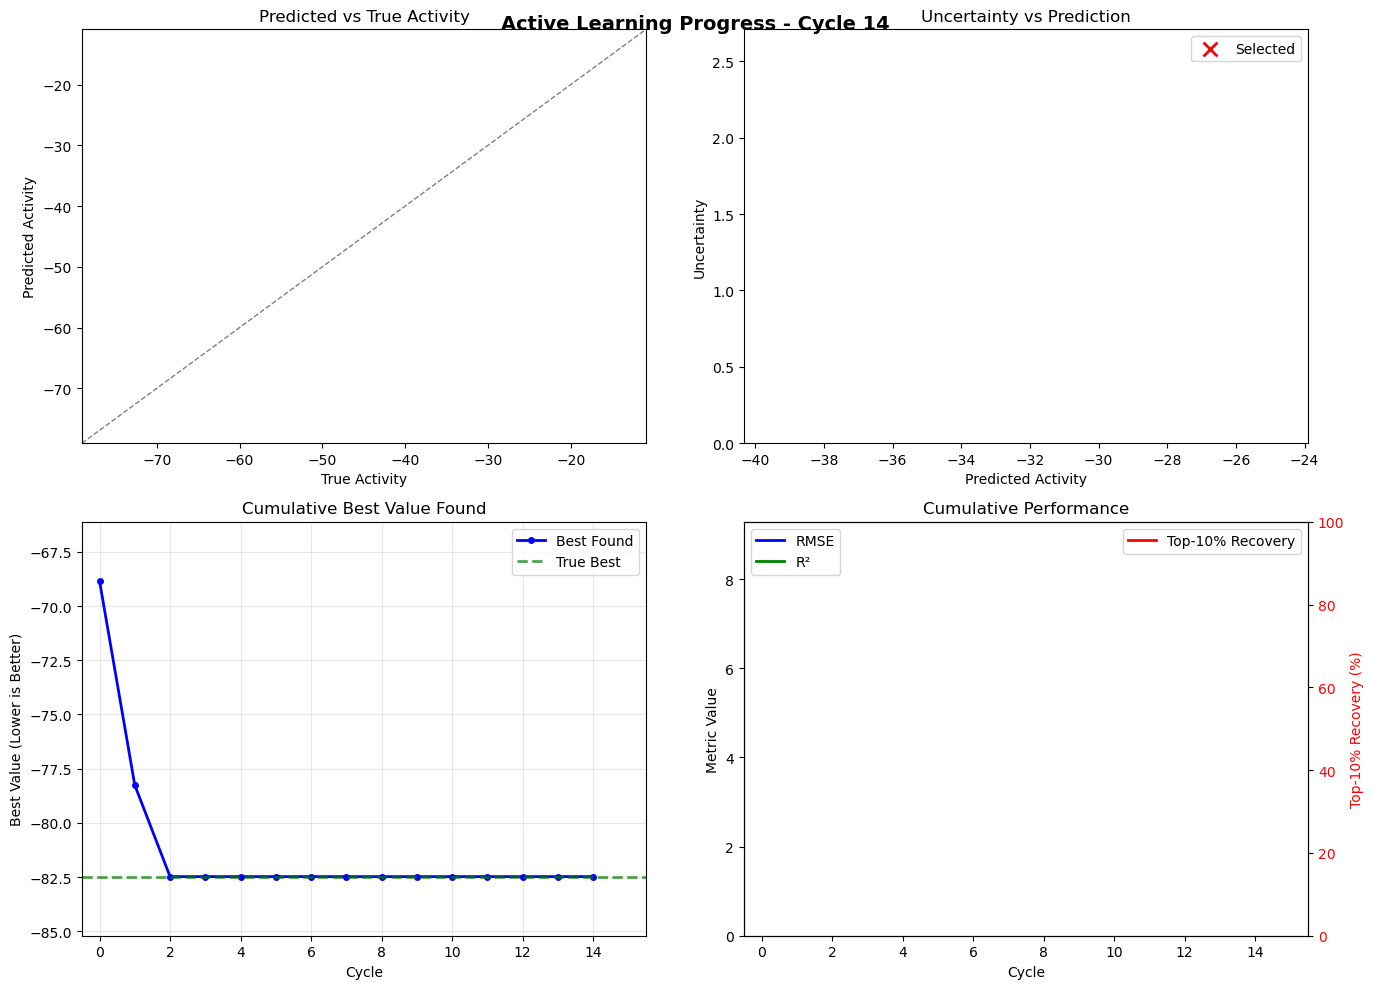

In [5]:
anim = create_dashboard_animation_from_csv(
    output_dir='viz_demo_results',
    output_file='viz_demo_results/al_progress.gif',
    format='gif',
    fps=2,
    dpi=100
)

print("✓ Animation created: viz_demo_results/al_progress.gif")

## Display Animation in Notebook

In [8]:
HTML('<img src="viz_demo_results/al_progress.gif">')

## Compare Different Acquisition Strategies

Run multiple strategies and compare their visualizations on the same AmpC dataset.

This comparison shows how different acquisition strategies navigate the chemical space and find strong binders.


Running GREEDY strategy


/home/tony/miniconda3/envs/learnm8/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 10000000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/tony/miniconda3/envs/learnm8/lib/python3.11/site-packages/sklearn/gaussian_process/_gpr.py:481: UserWarning: Predicted variances smaller than 0. Setting those variances to 0.
  warnings.warn(
/home/tony/miniconda3/envs/learnm8/lib/python3.11/site-packages/sklearn/gaussian_process/_gpr.py:481: UserWarning: Predicted variances smaller than 0. Setting those variances to 0.
  warnings.warn(
/home/tony/miniconda3/envs/learnm8/lib/python3.11/site-packages/sklearn/gaussian_process/_gpr.py:663: ConvergenceWarning: lbfgs failed to converge after 2 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/

✓ Completed greedy: 15 cycles

Running UCB strategy


/home/tony/miniconda3/envs/learnm8/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 10000000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/tony/miniconda3/envs/learnm8/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.0001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/tony/miniconda3/envs/learnm8/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 10000000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/tony

✓ Completed ucb: 15 cycles

Running THOMPSON strategy


/home/tony/LearnM8/learnm8/visualization/animation.py:237: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax3.set_ylim(cumulative_best[-1] - y_range * 0.2, cumulative_best[0] + y_range * 0.2)


✓ Completed thompson: 15 cycles

Running EI strategy


/home/tony/miniconda3/envs/learnm8/lib/python3.11/site-packages/sklearn/gaussian_process/_gpr.py:663: ConvergenceWarning: lbfgs failed to converge after 2 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/home/tony/miniconda3/envs/learnm8/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 10000000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/tony/miniconda3/envs/learnm8/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.0001. Decreasing the bound and calling fit again may find a better value.
  warnings

✓ Completed ei: 15 cycles

All strategies completed!


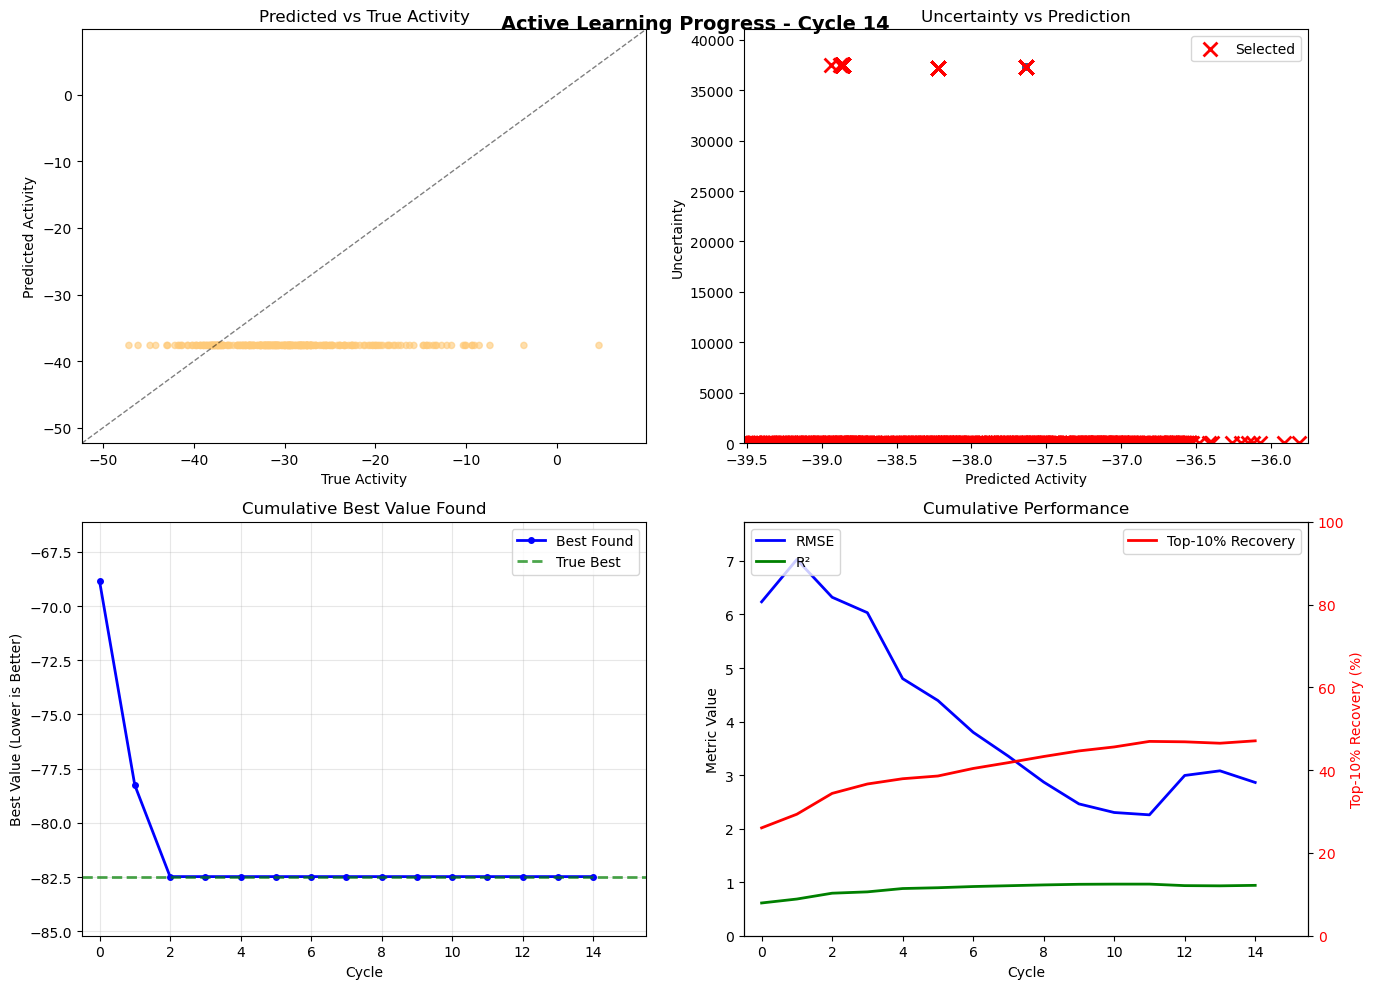

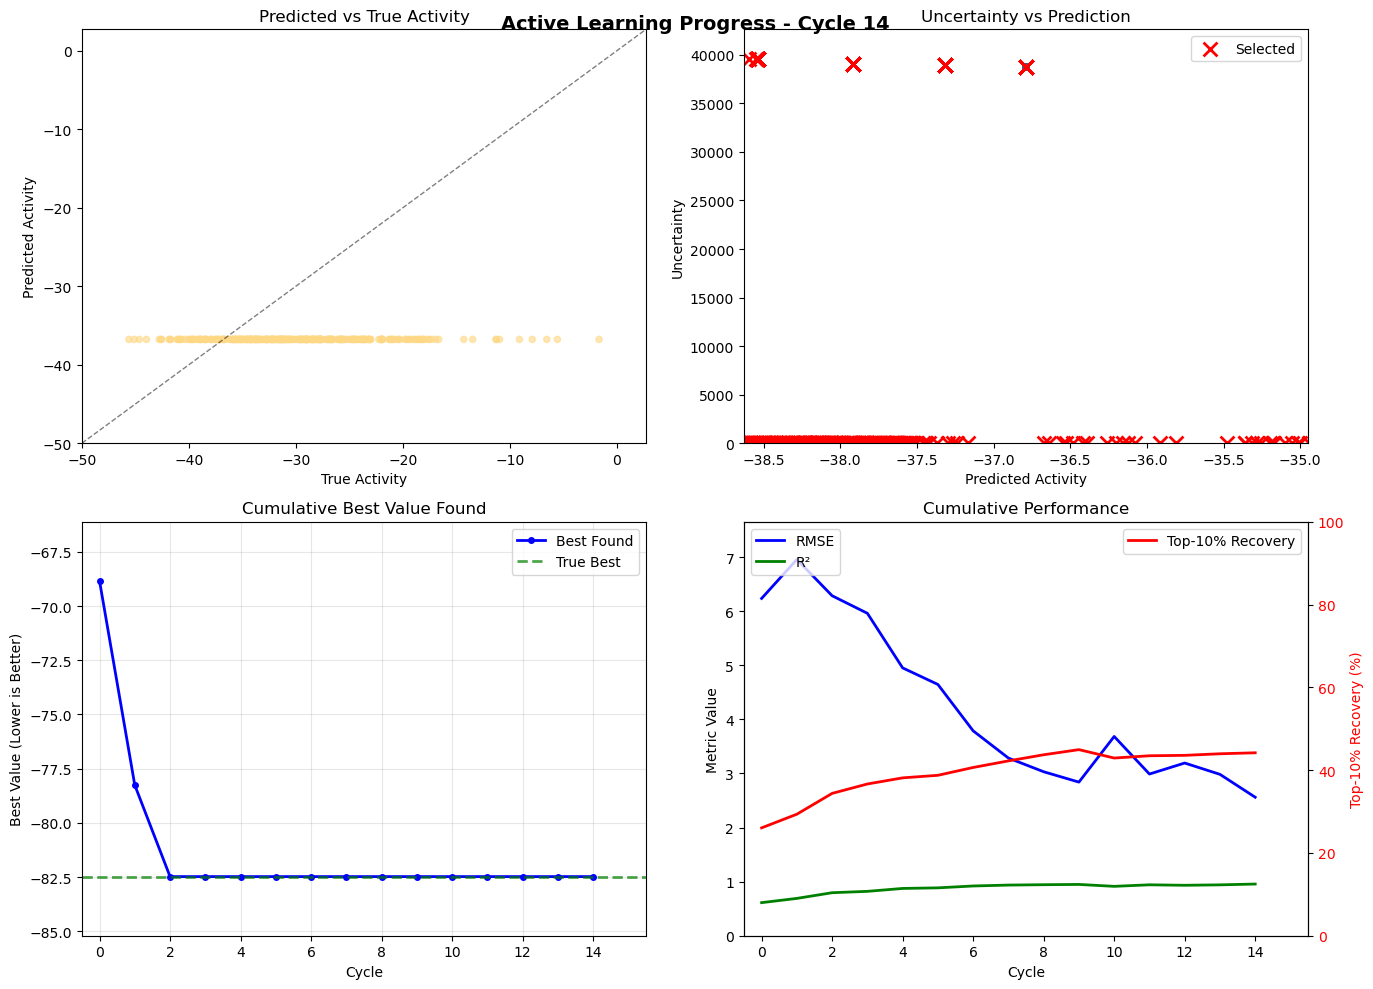

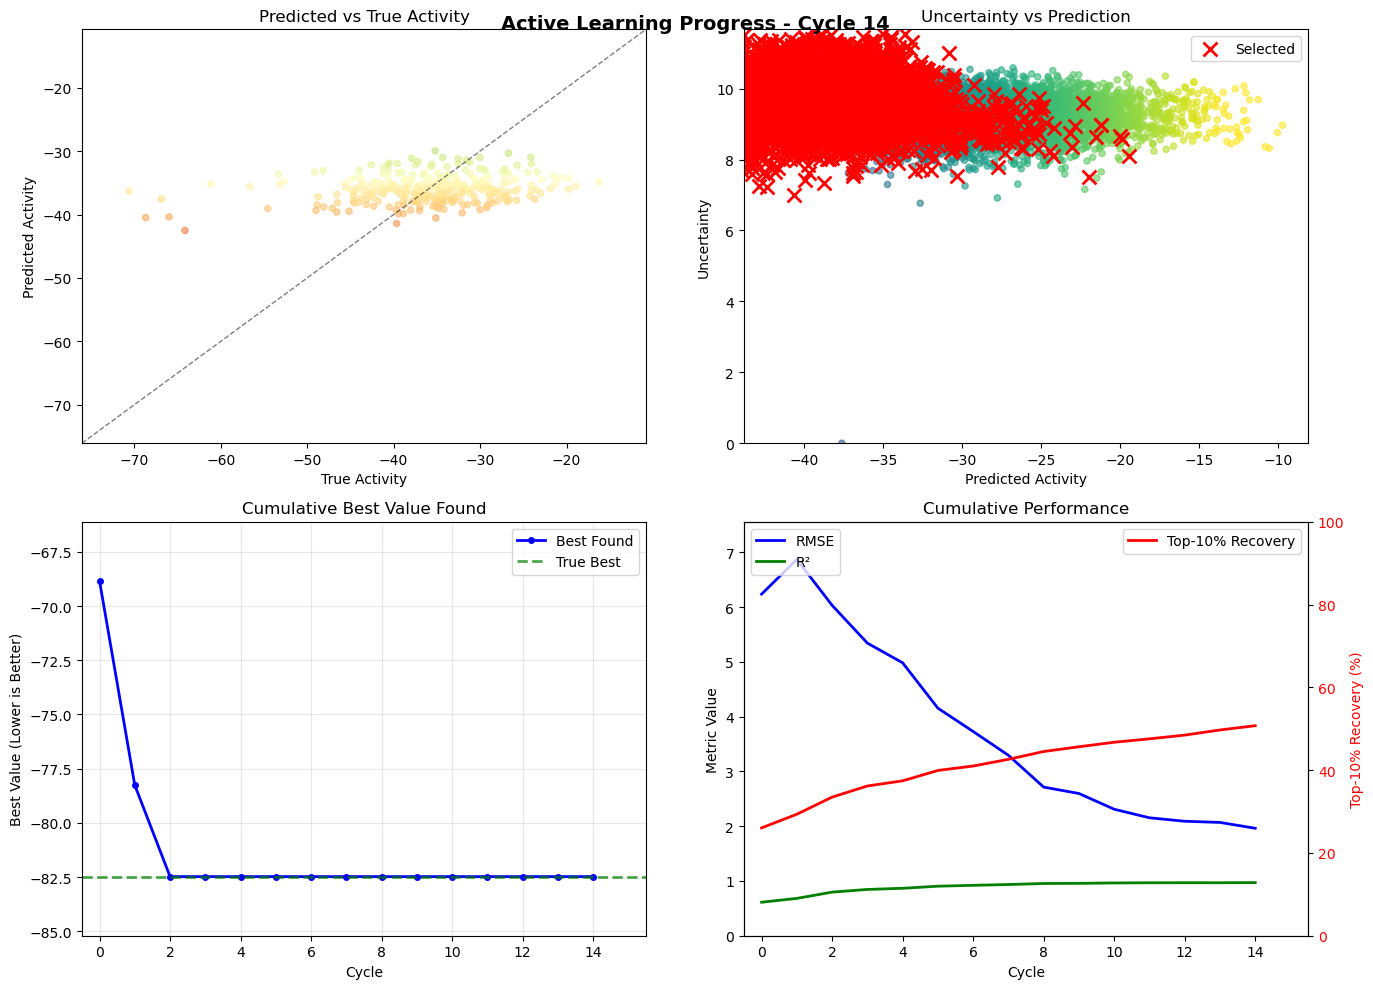

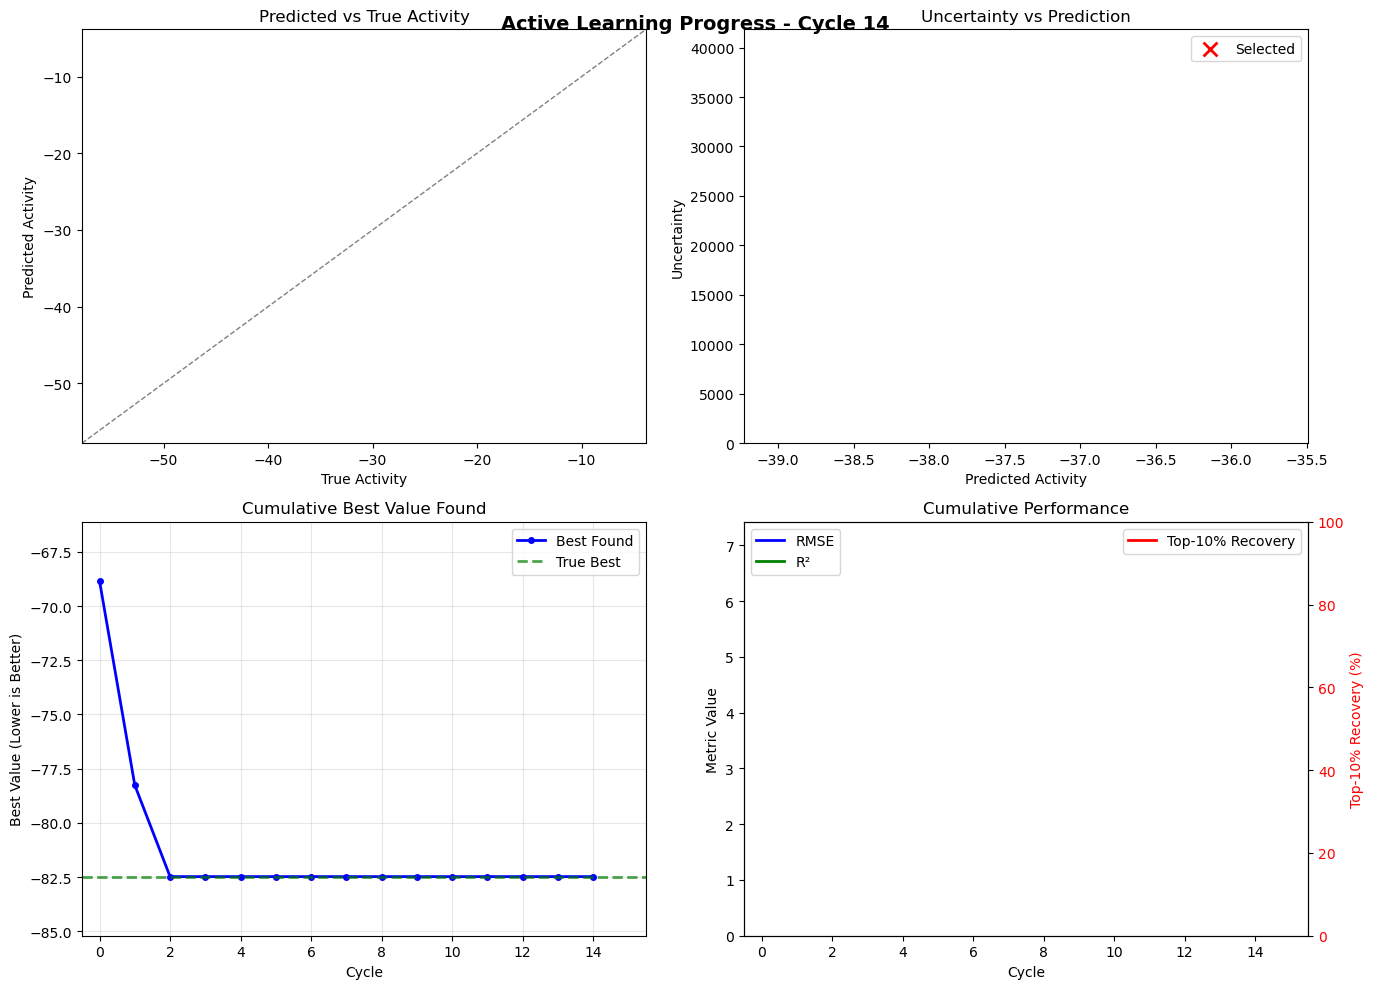

In [9]:
strategies = ['greedy', 'ucb', 'thompson', 'ei']
strategy_results = {}

for strategy in strategies:
    print(f"\n{'='*60}")
    print(f"Running {strategy.upper()} strategy")
    print(f"{'='*60}")
    
    results = run_active_learning(
        compound_pool=compound_pool,
        oracle=oracle,
        learner='gp',
        target_column='dockscore',
        featurizer='morgan',
        strategy=strategy,
        n_cycles=15,
        initial_batch_fraction=0.01,
        batch_fraction=0.01,
        score_direction='lower',
        export_csv=True,
        output_dir=f'viz_comparison_{strategy}',
        console_output=False
    )
    
    strategy_results[strategy] = results
    
    anim = create_dashboard_animation_from_csv(
        output_dir=f'viz_comparison_{strategy}',
        output_file=f'viz_comparison_{strategy}/al_progress_{strategy}.gif',
        format='gif',
        fps=2
    )
    
    print(f"✓ Completed {strategy}: {results['total_cycles']} cycles")

print("\n" + "="*60)
print("All strategies completed!")
print("="*60)

## Compare Final Performance

Extract final cycle metrics for each strategy to compare efficiency.

In [10]:
comparison_data = []

for strategy in strategies:
    metrics_file = f'viz_comparison_{strategy}/cycle_metrics.csv'
    metrics_df = pd.read_csv(metrics_file, comment='#')
    final_metrics = metrics_df.iloc[-1]
    
    comparison_data.append({
        'Strategy': strategy.upper(),
        'Final RMSE': final_metrics['rmse'],
        'Final R²': final_metrics['r2_score'],
        'Top-10% Recovery': final_metrics.get('top_10_percent_overlap', 'N/A'),
        'Compounds Labeled': final_metrics['cumulative_labeled']
    })

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*60)
print("FINAL PERFORMANCE COMPARISON")
print("="*60)
print(comparison_df.to_string(index=False))


FINAL PERFORMANCE COMPARISON
Strategy  Final RMSE  Final R²  Top-10% Recovery  Compounds Labeled
  GREEDY      2.8624    0.9408             47.09               4640
     UCB      2.5608    0.9554             44.20               4640
THOMPSON      1.9616    0.9698             50.74               4640
      EI      2.8810    0.9422             45.75               4640


## Summary

### What the Visualization Shows

The 4-panel dashboard provides comprehensive insights into active learning progress:

1. **Panel 1 - Predicted vs True Activity**: 
   - Shows how well the model predicts docking scores
   - Points closer to diagonal = better predictions
   - Evolves as more data is labeled

2. **Panel 2 - Uncertainty vs Prediction**:
   - Shows exploration-exploitation trade-off
   - High uncertainty regions = unexplored chemical space
   - Low uncertainty = confident predictions

3. **Panel 3 - Prediction Distribution**:
   - Histogram of predicted docking scores
   - Shows where the acquisition strategy focuses sampling
   - Changes over cycles as model learns

4. **Panel 4 - Cumulative Performance**:
   - RMSE (blue): Prediction error decreases over cycles
   - R² (green): Model fit improves over cycles
   - Top-10% Recovery (red): Enrichment in finding best binders

### Acquisition Strategy Behaviors

Different strategies show distinct patterns:

- **Greedy**: Focuses on lowest predicted docking scores (exploitation)
  - Fast convergence to good predictions
  - May miss diverse chemical space

- **UCB (Upper Confidence Bound)**: Balances good predictions and high uncertainty
  - Explores uncertain regions while exploiting known good areas
  - Better chemical space coverage

- **Thompson Sampling**: Probabilistic sampling from posterior distribution
  - Natural exploration-exploitation balance
  - Adaptive to uncertainty

- **EI (Expected Improvement)**: Focuses on expected improvement over current best
  - Conservative exploration
  - Good for finding marginal improvements

### AmpC Dataset Context

This demo uses real docking scores from AmpC β-lactamase inhibitor screening:
- **Dataset**: 5,000 compounds subsampled from 100K library
- **Target**: AmpC β-lactamase enzyme
- **Scores**: Docking scores (lower = stronger binding)
- **Goal**: Efficiently identify potential inhibitors

### Key Takeaways

1. **Visual feedback is crucial**: The animation shows how AL strategies explore chemical space
2. **Strategy matters**: Different acquisitions show different exploration patterns
3. **Uncertainty is valuable**: GP uncertainty guides intelligent exploration
4. **Real-time monitoring**: Visualizations enable mid-run decision making

### Next Steps

- Try different learners (ensemble, MC Dropout)
- Experiment with custom acquisition strategies
- Scale to larger compound libraries
- Add chemical space UMAP projection for spatial visualization